In [31]:
import numpy as np 
import matplotlib.pyplot as plt 

In [32]:
from pathlib import Path

def import_csv_to_array(directory, filename=None, delimiter=',', skip_header=0):
    """Load CSV data from a directory into a 2D NumPy array."""
    directory_path = Path(directory)

    if not directory_path.is_dir():
        raise FileNotFoundError(f'Directory not found: {directory_path}')

    if filename is None:
        csv_files = sorted(directory_path.glob('*.csv'))
        if not csv_files:
            raise FileNotFoundError(f'No CSV files found in: {directory_path}')
        csv_path = csv_files[0]
    else:
        csv_path = directory_path / filename
        if not csv_path.is_file():
            raise FileNotFoundError(f'CSV file not found: {csv_path}')

    data = np.loadtxt(csv_path, delimiter=delimiter, skiprows=skip_header)
    return np.atleast_2d(data)

# Example:
# data = import_csv_to_array('1D_OMC_hole/03272026', 'optimizeData_trial2_03272026.csv')
# print(data.shape)


In [33]:
data = import_csv_to_array('1D_OMC_hole/03272026', 'optimizeData_trial2_03272026.csv')
print(data.shape)

(63, 12)


## load the data into corresponding arrays 

In [34]:
fitness = data[:,-1]
gOM = np.abs(data[:,-2])
mech_freq = data[:,-3]
opt_lambda = data[:,-4]
opt_Q = data[:,-5]

# plot the optimization results 

Text(0, 0.5, 'fitness')

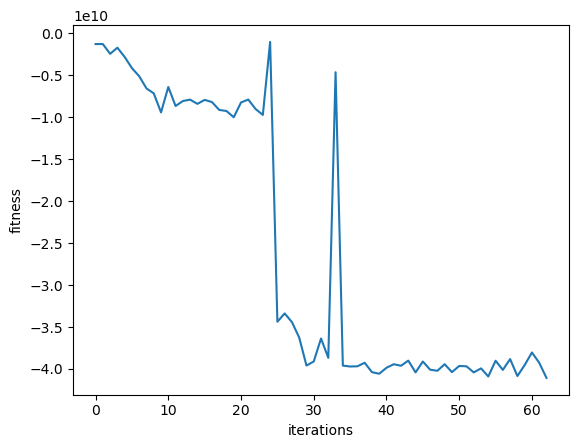

In [35]:
plt.plot(fitness)
plt.xlabel('iterations')
plt.ylabel('fitness')

Text(0, 0.5, '$g_{OM}$ (kHz)')

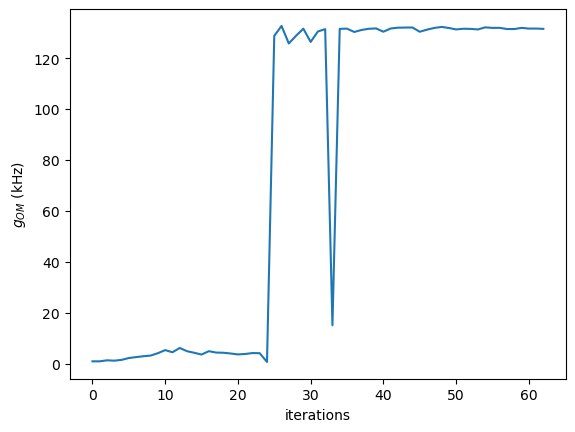

In [36]:
plt.plot(gOM/(1e3))
plt.xlabel('iterations')
plt.ylabel(r'$g_{OM}$ (kHz)')

Text(0, 0.5, '$g_{OM}$')

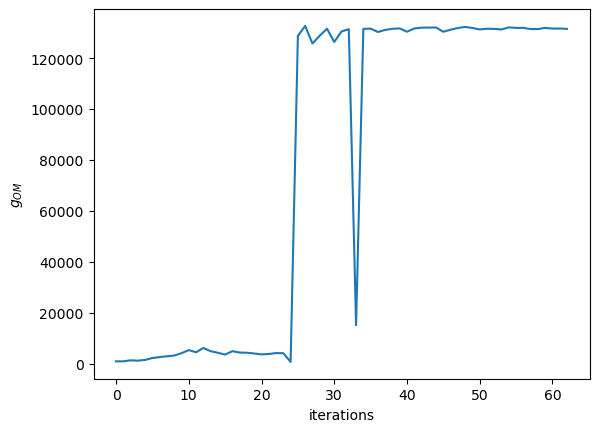

In [37]:
plt.plot(gOM)
plt.xlabel('iterations')
plt.ylabel(r'$g_{OM}$')

In [39]:
headers = ['maxdef', 'oblong', 'a', 'w', 'th', 'hx', 'hy', 'optQ', 'optLambda', 'mechFreq', 'gOM', 'fitness']

opt_idx = np.argmin(fitness)  # change this to print a different row
row_data = data[opt_idx]

if len(row_data) != len(headers):
    raise ValueError(f'Row has {len(row_data)} columns, but {len(headers)} headers were provided.')

print(f'Row {opt_idx}:')
for header, value in zip(headers, row_data):
    print(f'{header}: {value}')


Row 62:
maxdef: 0.132916259765625
oblong: 0.75215630493164
a: 5.5e-07
w: 6e-07
th: 4e-07
hx: 2.2e-07
hy: 3.3e-07
optQ: 667947.525028729
optLambda: 1.50640746368814e-06
mechFreq: 9630122521.39183
gOM: -131502.009980954
fitness: -41073074444.4607
